In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

run = pickle.loads(Path(".run.pkl").read_bytes())
card, ev, constants = run["card"], run["evidence"], run["constants"]
gates = {g["number"]: g for g in run["gates"]}
pd.set_option("display.max_colwidth", None)
plt.rcParams.update({"figure.figsize": (9, 3), "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10})
INK, GREY, MARK = "#1f4e79", "#a6a6a6", "#c0504d"


def text(value):
    return " ".join(str(value).split()) if value else "—"


def shown(value):
    if value is None:
        return "—"
    if isinstance(value, (list, tuple)):
        return "; ".join(map(str, value)) or "none"
    if isinstance(value, float):
        return float(f"{value:.4g}")
    return value


def table(figures):
    display(pd.Series({k: shown(v) for k, v in figures.items()}, dtype=object).to_frame().T.set_index(pd.Index([""])))


def gate(number):
    g = gates[number]
    reason = g["reason"].removeprefix("not computed: ")
    word = {True: "Passes", False: "Fails", None: "Not computed"}[g["passed"]]
    display(Markdown(f"**{word}**: {reason.rstrip('.')}."))
    if g["figures"]:
        table(g["figures"])


failed = run["failed"]
headline = ("passes gates 1 to 7" if failed is None
            else f"stops at gate {failed}, {gates[failed]['name'].lower()}: {gates[failed]['reason']}")
display(Markdown(f"# {card['id']}\n\nTheory **{card.get('theory', '—')}**. The battery's verdict: "
                 f"the strategy {headline}."))

# TM-023-01-quarter-end-momentum

Theory **TM-023**. The battery's verdict: the strategy stops at gate 2, economic edge: Sharpe 0.447 against the benchmark's 0.457, alpha -0.00%; at twice the costs, Sharpe 0.419 and alpha -0.49%.

## Thesis

In [2]:
prediction = card.get("prediction") or {}
if isinstance(prediction, dict):
    prediction = ", ".join(f"{k}: {v}" for k, v in prediction.items())
display(Markdown(f"**Mechanism.** {text(card.get('mechanism'))}\n\n"
                 f"**Prediction.** {text(prediction)}\n\n"
                 f"**What would refute it.** {text(card.get('refuted_if'))}\n\n"
                 f"**Horizon.** {text(card.get('horizon'))}"))

**Mechanism.** Before quarter-ends and the year's end, fund managers dress their reports with the period's winners and taxable investors sell its losers, pushing winners up and losers down; in January the pressure lifts and the losers rebound. Momentum is therefore stronger in the months that end a quarter and weaker in January than in the other months.

**Prediction.** sign: positive (the leaders' gap to their group's ranked funds higher in the months that end a quarter than in the other months outside January); negative (lower in January), size: a judgment -- the gap about +0.5 to +5% a year higher in the months that end a quarter and about -0.5 to -6% a year lower in January, the library's long-short spreads on stocks and industries halved for a long-only top third and cut to between a tenth and a third for a momentum the funds carried weakly (CA-001-01, its base, this ranking, a tenth of its prediction; its variant without the skip, a third); the rule's alpha over the groups in equal parts about -0.3 to +0.6% a year, its Sharpe ratio close to theirs; the base expected to fail gates 2, 3, 4 and 5

**What would refute it.** Judged before costs, on the market's closes, over the in-sample calendar months from February 2006, the month of the first target on which a fund is ranked, to December 2022, each group-month from the close of the session before the month's first session to the close of the month's last session -- the calendar month the sources measure -- the last ending at the close of 2022-12-30, over the group-months with two ranked funds or more, the sector group's December and January group-months left out (SC-006-01 has published the sector winners less the other sector funds over parts of those months): the return of the group's leaders -- CA-001-01's top third of the group's funds ranked for the month's target, with lookback 252 and skip 21, bought in equal parts at the close of the session before the month's first session and held -- less the return of all the group's ranked funds bought and held the same way. An ordinary least-squares regression of the gaps on two indicators, the group-months of March, June, September and December, and those of January, and one constant for each group, the standard errors clustered by month, the groups' gaps in each of the 203 months from February 2006 to December 2022 one cluster, the coefficients' t statistics computed apart from the battery. The quarter-end half of the theory is refuted in this form if its coefficient's t statistic is -0.35 or below: momentum no stronger in the months that end a quarter than in the other months outside January. The January half is refuted in this form if its coefficient's t statistic is +0.35 or above: momentum no weaker in January. Between, short of passing gates 1 to 7, each half is not proven, not refuted; a base that passes gates 1 to 7 while a half refutes leaves that half refuted in this form. Of TM-023's refutation criteria the first and second are graded, the first in its momentum part, against the other months outside the quarter-ends; the losers' rebound is left to FP-026, whose graded quantity it is; the third cannot be read apart from tax years and reporting dates, which every market the lab trades has; the fourth reads the production and consumption cycles the library signs on agricultural commodities, which the lab holds only inside a broad basket; the seasons it finds for silver are of returns, not of momentum. Reported, not graded: the sector group's December and January group-months, apart; the same regression on the rule's months, each group-month from the close of the month's first session to the close of the next month's first session; the same regression without TM-024-01's panic group-months (its base's states, vol_window 126 and bear_window 504), the calendar group-months whose target falls in a panic state; January against every other month, one indicator and the group constants; the gap by month of the year, pooled and by group, with the number of group-months in each; December alone against the other months that end a quarter, over the graded group-months (the equity markets and the commodities); the regression on the gaps hedged of their group's market, one beta for each set; the rule and the variant against CA-001-01 by lab.compare, the alpha's difference and its standard error on the monthly differences; the clause over the months of 2006 to 2013, over those of 2014 to 2022, over the in-sample months without 2008 and 2009, and over the holdout, 2023 to 2025; the base's alpha before and after costs, and the neighbours' and the one-day-late rule's alphas and appraisal ratios.

**Horizon.** months

## Data

In [3]:
x = ev.get("excess")
start, end = constants["in sample"]
cannot_run = gates[1]["reason"].startswith("the strategy cannot run")
broke = gates[1]["reason"].startswith("cannot be computed: ")        # the runs every gate judges broke
evaluated = (f"evaluated from the first session the strategy holds an asset, {x.index[0].date()}, to "
             f"{x.index[-1].date()}" if x is not None and len(x)
             else "not evaluated: the strategy cannot run" if cannot_run
             else f"not evaluated: the runs every gate judges broke ({gates[1]['reason'].split(': ', 1)[1]})"
             if broke else "not evaluated: nothing was held")
display(Markdown(
    f"Daily closes adjusted for dividends and splits, snapshot **{run['snapshot']}**. "
    f"Universe: {', '.join(card['universe'])}. In-sample {start} to {end}, {evaluated}; "
    f"holdout {' to '.join(constants['holdout'])}, opened once, at gate 7. "
    f"Returns are above the Treasury-bill rate, net of costs."))

Daily closes adjusted for dividends and splits, snapshot **2026-09-22+2026-09-23**. Universe: XLB, XLC, XLE, XLF, XLI, XLK, XLP, XLRE, XLU, XLV, XLY, SPY, QQQ, IWM, EFA, EEM, GLD, SLV, DBC. In-sample 2005-01-01 to 2022-12-31, evaluated from the first session the strategy holds an asset, 2006-02-02, to 2022-12-30; holdout 2023-01-01 to 2025-12-31, opened once, at gate 7. Returns are above the Treasury-bill rate, net of costs.

## Signal

CA-001-01's momentum rule sets each group's tilt: within each of three groups (the eleven sector funds; SPY, QQQ, IWM, EFA and EEM; GLD, SLV and DBC), the funds are ranked by their return over a window read up to the session before the target, ending skip sessions and starting lookback sessions before that session before; a fund is ranked when it trades on the target's session and traded on the window's first session, with a return over the window; the top third of each group's ranked funds, rounded half to even, one at least, share the group's n/N of the portfolio, and a fund trading but not yet ranked holds 1/N. The tilt is those weights less the group held in equal parts, 1/N for each fund trading. Each group holds its funds in equal parts plus k times its tilt: in the base, k = 1 when the target's month is March, June, September or December, the months that end a quarter, and 0 in the other months; in the variant, k = 0 when the target's month is January and 1 in the other months. Everything is read up to the session before; targets are set on the first session of each month on which a fund is ranked, fully invested.

- **lookback**: sessions from the start of the ranking window to the session before the target
- **skip**: sessions before the session before the target left out of the ranking window
- **months**: the target months in which the tilt is held, a text naming the variant, with no neighbours: "quarter-ends", March, June, September and December; "all-but-january", every month but January

,lookback,skip,months
base,252,21,quarter-ends
variant 1,252,21,all-but-january


Parameter neighbours, moved one at a time for gate 6: lookback at ±25%: 189, 315; lookback at ±50%: 126, 378; skip at ±25%: 16, 26; skip at ±50%: 10, 32.

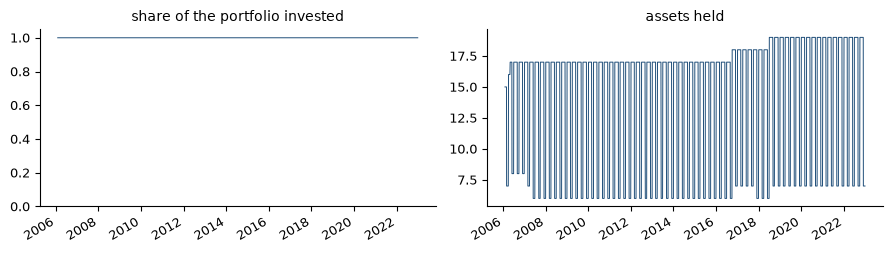

In [4]:
display(Markdown(text(card.get("signal"))))
parameters = card.get("parameters") or {}
if parameters:
    display(Markdown("\n".join(f"- **{k}**: {text(v)}" for k, v in parameters.items())))
variants = pd.DataFrame(card["variants"], index=["base"] + [f"variant {k}" for k in range(1, len(card["variants"]))])
display(variants)
neighbours = card.get("neighbours") or {}
if neighbours:
    display(Markdown("Parameter neighbours, moved one at a time for gate 6: "
                     + "; ".join(f"{p} at ±{step}%: {', '.join(map(str, values))}"
                                 for p, steps in neighbours.items() for step, values in steps.items()) + "."))
if "exposure" in ev:
    fig, (a, b) = plt.subplots(1, 2, figsize=(9, 2.6))
    ev["exposure"].plot(ax=a, color=INK, linewidth=0.7)
    a.set_title("share of the portfolio invested")
    a.set_ylim(0, 1.05)
    ev["assets held"].plot(ax=b, color=INK, linewidth=0.7)
    b.set_title("assets held")
    for axis in (a, b):
        axis.set_xlabel("")
    plt.tight_layout()

## Equity against the benchmark

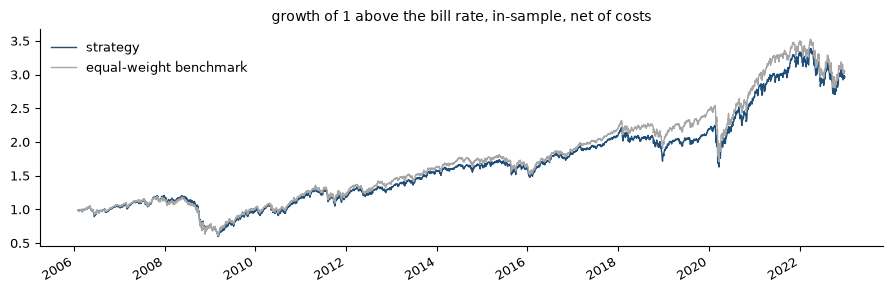

In [5]:
if x is not None and len(x):
    b = ev["benchmark excess"]
    fig, ax = plt.subplots()
    (1 + x).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + b).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title("growth of 1 above the bill rate, in-sample, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
else:
    display(Markdown("The strategy cannot run: there is no equity to draw." if cannot_run
                     else "The runs every gate judges broke: there is no equity to draw." if broke
                     else "Nothing was held in-sample: there is no equity to draw."))

## Gate 1 · Hygiene

Protects against look-ahead, bad data and too little evidence.

**Passes**: no look-ahead on 200 dates, 137 decisions over 16.9 years.

,dates checked,look-ahead breaks,same-day breaks,memory,memory dates checked,memory breaks,data problems,clustered decisions,years in-sample,years needed
,200,0,0,252,100,0,none,137,16.9,5


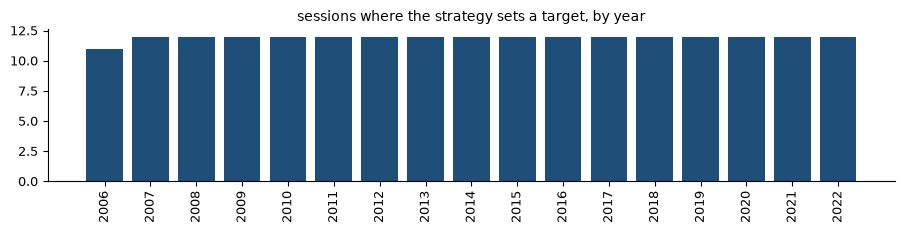

In [6]:
gate(1)
days = ev.get("target days")
if days is not None and len(days):
    per_year = pd.Series(1, index=days).groupby(days.year).sum()
    fig, ax = plt.subplots(figsize=(9, 2.4))
    ax.bar(per_year.index.astype(str), per_year, color=INK)
    breaks = sorted({d.year for variant in ev["timing breaks"].values() for kind in variant.values() for d in kind})
    for year in breaks:
        ax.bar(str(year), per_year.get(year, 0), color=MARK)
    ax.set_title("sessions where the strategy sets a target, by year" + ("; red: a timing break" if breaks else ""))
    ax.tick_params(axis="x", rotation=90)
    plt.tight_layout()

## Gate 2 · Economic edge

Protects against an edge explained by costs or by market exposure.

**Fails**: Sharpe 0.447 against the benchmark's 0.457, alpha -0.00%; at twice the costs, Sharpe 0.419 and alpha -0.49%.

,Sharpe,benchmark Sharpe,alpha,Sharpe at 2x costs,alpha at 2x costs,gross Sharpe,costs a year,costs in Sharpe units
,0.4473,0.4567,-0.000025,0.4191,-0.004934,0.4757,0.005136,0.02844


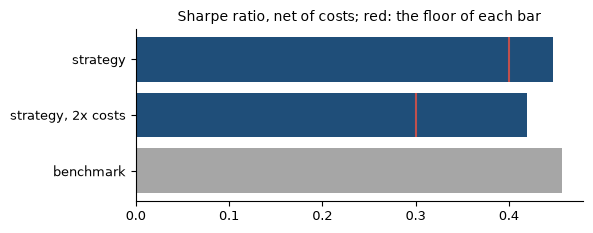

In [7]:
gate(2)
f = gates[2]["figures"]
if f:
    floors = constants["floors"]
    rows = [("benchmark", f["benchmark Sharpe"], GREY, None),
            ("strategy, 2x costs", f["Sharpe at 2x costs"], INK, floors["Sharpe at 2x costs"]),
            ("strategy", f["Sharpe"], INK, floors["Sharpe"])]
    fig, ax = plt.subplots(figsize=(6, 2.4))
    for y, (label, value, colour, floor) in enumerate(rows):
        ax.barh(y, value, color=colour)
        if floor is not None:
            ax.vlines(floor, y - 0.4, y + 0.4, color=MARK, linewidth=1.5)
    ax.set_yticks(range(len(rows)), [r[0] for r in rows])
    ax.set_title("Sharpe ratio, net of costs; red: the floor of each bar")
    plt.tight_layout()

## Gate 3 · Significance

Protects against luck, and against being paid only for being invested. A strategy that holds nearly every asset that trades is close to its benchmark: its placebos differ from it by little, details of the path decide its rank, and gates 2 and 4 judge it.

**Fails**: beats 66.7% of its shifted placebos, fewer than 90%.

,PSR,placebo sessions,placebos,placebos beaten
,0.9827,4259,1000,0.667


Assets that start trading after 2006-02-01: XLC, XLRE, SLV, DBC. A placebo shifts their weights only between days when they trade. Where it draws from a day before their start, it keeps their own weights; where it draws from a day after their start onto a day before it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its timing: skill that lies before a late start is judged against placebos that share it, and is found less often. Where the strategy holds none of the assets shifted that day, the shifted weights take that share instead.

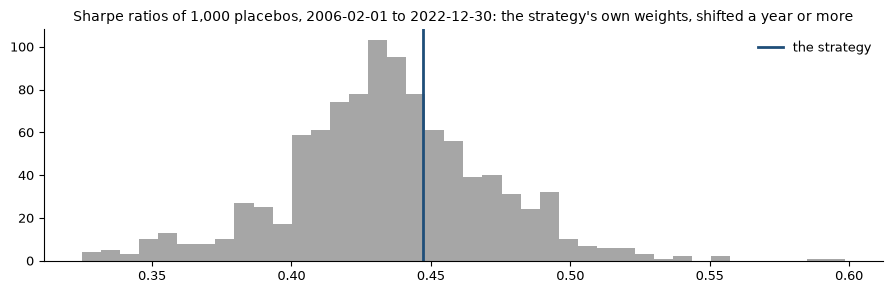

In [8]:
gate(3)
if "placebos" in ev:
    fig, ax = plt.subplots()
    ax.hist(ev["placebos"], bins=40, color=GREY)
    ax.axvline(ev["placebo own Sharpe"], color=INK, linewidth=2, label="the strategy")
    first, last = (d.date() for d in ev["placebo window"])
    ax.set_title(f"Sharpe ratios of {len(ev['placebos']):,} placebos, {first} to {last}: the strategy's own weights, "
                 f"shifted a year or more")
    ax.legend(frameon=False)
    plt.tight_layout()
    if ev.get("placebo late assets"):
        display(Markdown(f"Assets that start trading after {first}: {', '.join(ev['placebo late assets'])}. A placebo "
                         f"shifts their weights only between days when they trade. Where it draws from a day before their "
                         f"start, it keeps their own weights; where it draws from a day after their start onto a day before "
                         f"it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its "
                         f"timing: skill that lies before a late start is judged against placebos that share it, and is "
                         f"found less often. Where the strategy holds none of the assets shifted that day, the shifted "
                         f"weights take that share instead."))

## Gate 4 · Multiple testing

Protects against the best of many tries: the edge, hedged of the benchmark, deflated by every trial the registry holds.

**Fails**: DSR 0.005 below 0.9 over 55 effective trials.

,trials,effective trials,appraisal ratio,Sharpe expected by luck,DSR
,60,55,-0.00068,0.6217,0.005258


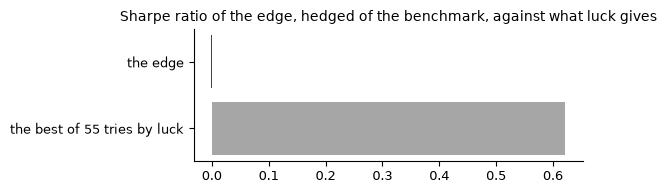

In [9]:
gate(4)
f = gates[4]["figures"]
if f and "appraisal ratio" in f:
    fig, ax = plt.subplots(figsize=(6, 2.0))
    ax.barh([0, 1], [f["Sharpe expected by luck"], f["appraisal ratio"]], color=[GREY, INK])
    tries = f["effective trials"]
    ax.set_yticks([0, 1], [f"the best of {tries} {'try' if tries == 1 else 'tries'} by luck", "the edge"])
    ax.set_title("Sharpe ratio of the edge, hedged of the benchmark, against what luck gives")
    plt.tight_layout()

## Gate 5 · Stability

Protects against an edge that lives in one variant or one episode.

**Fails**: the blend of the variants fails gates 2, 3 and 4; alpha -0.45% without its best year, 2020.

,blend passes gate 2,blend passes gate 3,blend passes gate 4,worst variant Sharpe,positive blocks,best year,alpha without the best year
,False,False,False,0.4238,3,2020,-0.004529


The blend of the variants: gate 2, Sharpe 0.439 against the benchmark's 0.457, alpha -0.08%; at twice the costs, Sharpe 0.416 and alpha -0.48%; gate 3, beats 48.2% of its shifted placebos, fewer than 90%; gate 4, DSR 0.004 below 0.9 over 55 effective trials.

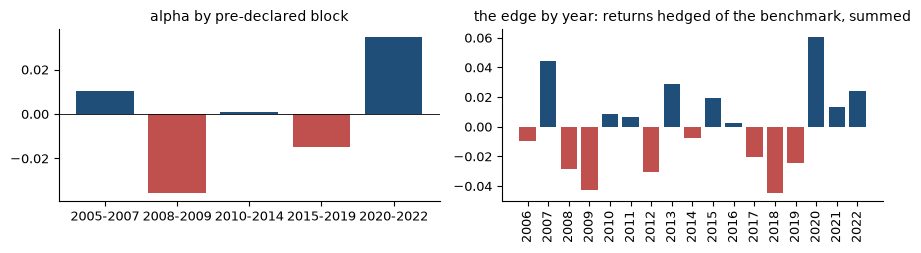

In [10]:
gate(5)
if "blocks" in ev:
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    blocks = pd.Series({k: (v if v is not None else np.nan) for k, v in ev["blocks"].items()})
    a.bar(blocks.index, blocks.fillna(0), color=[INK if v > 0 else MARK for v in blocks.fillna(0)])
    a.set_title("alpha by pre-declared block")
    a.axhline(0, color="black", linewidth=0.6)
    by_year = ev["edge by year"]
    c.bar(by_year.index.astype(str), by_year, color=[INK if v > 0 else MARK for v in by_year])
    c.set_title("the edge by year: returns hedged of the benchmark, summed")
    c.tick_params(axis="x", rotation=90)
    plt.tight_layout()
failed_blend = {n: reason for n, reason in ev.get("blend", {}).items() if gates[5]["figures"].get(f"blend passes gate {n}") is False}
if failed_blend:
    display(Markdown("The blend of the variants: " + "; ".join(f"gate {n}, {r}" for n, r in failed_blend.items()) + "."))

## Gate 6 · Robustness

Protects against a peak, one asset, timing too tight and a clone.

**Passes**: neighbours, clusters, assets, bitcoin, delay and survivors all hold.

,neighbour median ratio,lowest ±25% ratio,neighbours that hold the base,worst cluster out,worst cluster out ratio,largest P&L share,asset with the largest share,one day late ratio,highest correlation with a survivor,survivor most correlated
,1.008,0.9849,none,sectors,0.7954,0.09273,XLI,1.027,—,—


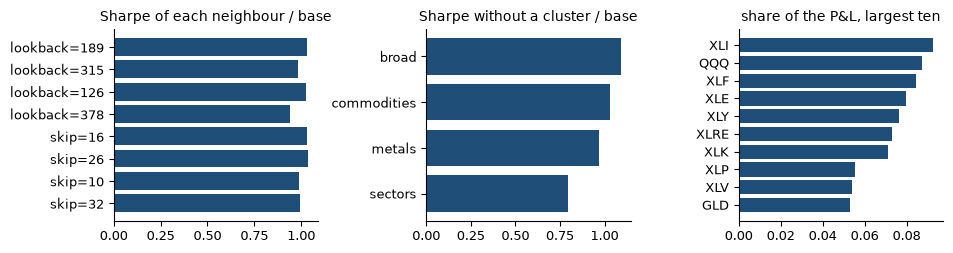

In [11]:
gate(6)
panels = [(k, ev.get(k)) for k in ("neighbours", "clusters out", "P&L shares") if ev.get(k) is not None and len(ev.get(k))]
if panels:
    fig, axes = plt.subplots(1, len(panels), figsize=(3.2 * len(panels), 2.6))
    for axis, (name, values) in zip(np.atleast_1d(axes), panels):
        values = pd.Series(values).head(10)
        axis.barh(values.index.astype(str), values, color=INK)
        axis.set_title({"neighbours": "Sharpe of each neighbour / base", "clusters out": "Sharpe without a cluster / base",
                        "P&L shares": "share of the P&L, largest ten"}[name])
        axis.invert_yaxis()
    plt.tight_layout()
if ev.get("without bitcoin"):
    display(Markdown("Without bitcoin, gate 2's figures:"))
    table(ev["without bitcoin"])

## Gate 7 · Sealed holdout

Protects against bugs and large decay, on years kept aside and opened once.

**Passes**: holdout Sharpe 0.96 and alpha -1.09%, both above the in-sample 10th percentile.

,holdout Sharpe,Sharpe floor,holdout alpha,alpha floor,variants rewritten,dates checked,look-ahead breaks,same-day breaks,data problems
,0.9565,-0.2851,-0.0109,-0.02633,0,40,0,0,none


Red: the 10th percentile of the in-sample paths, the floor; blue: the holdout.

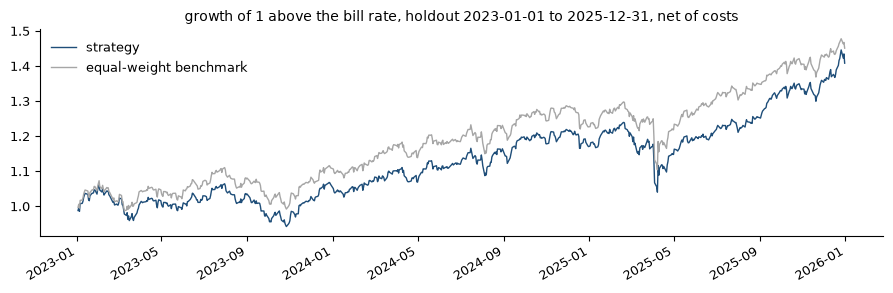

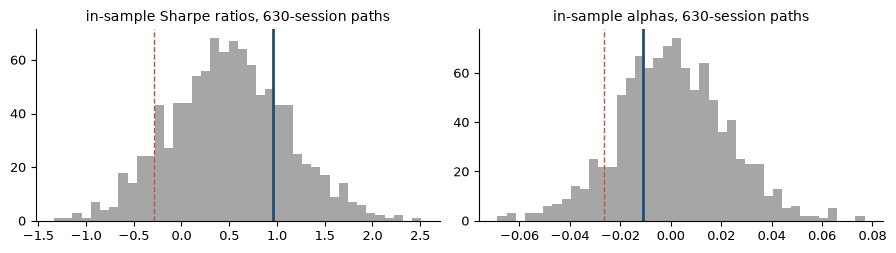

In [12]:
gate(7)
f = gates[7]["figures"]
if "holdout excess" in ev and len(ev["holdout excess"]):
    fig, ax = plt.subplots()
    (1 + ev["holdout excess"]).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + ev["holdout benchmark excess"]).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title(f"growth of 1 above the bill rate, holdout {' to '.join(constants['holdout'])}, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
if "bootstrap" in ev and f:
    pct = constants["percentile"]
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    for axis, key, mark, label in ((a, "Sharpe", "holdout Sharpe", "Sharpe ratio"), (c, "alpha", "holdout alpha", "alpha")):
        axis.hist(ev["bootstrap"][key], bins=40, color=GREY)
        axis.axvline(np.percentile(ev["bootstrap"][key], pct), color=MARK, linestyle="--", linewidth=1)
        axis.axvline(f[mark], color=INK, linewidth=2)
        axis.set_title(f"in-sample {label}s, {constants['window']}-session paths")
    plt.tight_layout()
    display(Markdown(f"Red: the {pct}th percentile of the in-sample paths, the floor; blue: the holdout."))

## Verdict

In [13]:
table = pd.DataFrame([{"gate": f"{g['number']} · {g['name']}",
                       "result": {True: "passes", False: "fails", None: "not computed"}[g["passed"]],
                       "reason": g["reason"].removeprefix("not computed: ")} for g in run["gates"]]).set_index("gate")
display(table)
display(Markdown(f"Thresholds, version {run['thresholds']}. What the verdict means for the theory, and what was "
                 f"learned, is written in [verdict.md](verdict.md)."))

,result,reason
gate,,
1 · Hygiene,passes,"no look-ahead on 200 dates, 137 decisions over 16.9 years"
2 · Economic edge,fails,"Sharpe 0.447 against the benchmark's 0.457, alpha -0.00%; at twice the costs, Sharpe 0.419 and alpha -0.49%"
3 · Significance,fails,"beats 66.7% of its shifted placebos, fewer than 90%"
4 · Multiple testing,fails,DSR 0.005 below 0.9 over 55 effective trials
5 · Stability,fails,"the blend of the variants fails gates 2, 3 and 4; alpha -0.45% without its best year, 2020"
6 · Robustness,passes,"neighbours, clusters, assets, bitcoin, delay and survivors all hold"
7 · Sealed holdout,passes,"holdout Sharpe 0.96 and alpha -1.09%, both above the in-sample 10th percentile"


Thresholds, version 4. What the verdict means for the theory, and what was learned, is written in [verdict.md](verdict.md).